<a href="https://colab.research.google.com/github/GustavoMMayer/mini-projeto-visao-computacional/blob/sprint-1-configuracao/Mini_Projeto_Visao_Computacional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

caminho_drive = "/content/drive/MyDrive"

for item in os.listdir(caminho_drive):
    print(item)

Colab Notebooks
Inventário de Valores.gdoc
Mini-Projeto Avaliativo - Módulo 2 - Semana 07


In [9]:
caminho_dataset = "/content/drive/MyDrive/Mini-Projeto Avaliativo - Módulo 2 - Semana 07/casting_512x512"

print(os.listdir(caminho_dataset))

['ok_front', 'def_front']


In [10]:
# Caminhos das duas classes
pasta_def = os.path.join(caminho_dataset, "def_front")
pasta_ok = os.path.join(caminho_dataset, "ok_front")

# Lista somente arquivos de imagem
imagens_def = [
    arquivo for arquivo in os.listdir(pasta_def)
    if arquivo.lower().endswith((".jpg", ".jpeg", ".png"))
]

imagens_ok = [
    arquivo for arquivo in os.listdir(pasta_ok)
    if arquivo.lower().endswith((".jpg", ".jpeg", ".png"))
]

# Quantidade de imagens
print("Imagens defeituosas:", len(imagens_def))
print("Imagens OK:", len(imagens_ok))
print("Total de imagens:", len(imagens_def) + len(imagens_ok))

Imagens defeituosas: 781
Imagens OK: 519
Total de imagens: 1300


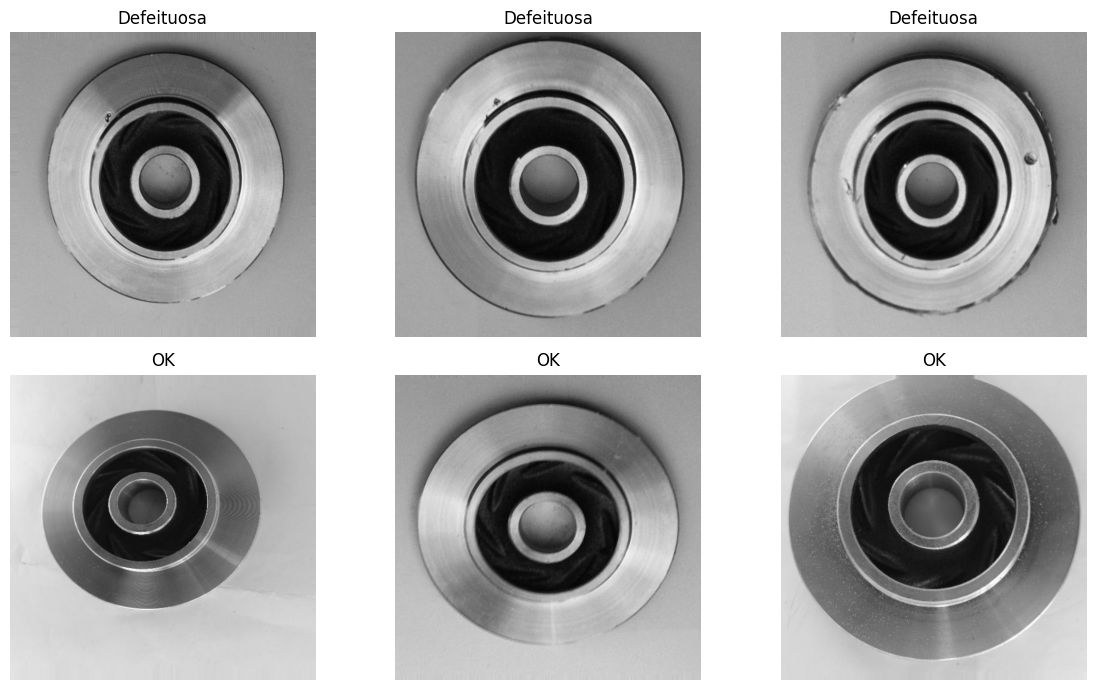

In [11]:
import matplotlib.pyplot as plt
from PIL import Image

# Cria uma figura com 6 espaços
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

# Mostra 3 imagens defeituosas
for i in range(3):
    caminho = os.path.join(pasta_def, imagens_def[i])
    imagem = Image.open(caminho)

    axes[0, i].imshow(imagem, cmap="gray")
    axes[0, i].set_title("Defeituosa")
    axes[0, i].axis("off")

# Mostra 3 imagens OK
for i in range(3):
    caminho = os.path.join(pasta_ok, imagens_ok[i])
    imagem = Image.open(caminho)

    axes[1, i].imshow(imagem, cmap="gray")
    axes[1, i].set_title("OK")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [12]:
# 4. Análise Exploratória com OpenCV

Nesta etapa será realizada uma análise visual das imagens utilizando técnicas
clássicas de processamento de imagens.

O objetivo é compreender as características visuais dos possíveis defeitos
presentes nas peças antes da aplicação de uma Rede Neural Convolucional.

Serão utilizadas as seguintes técnicas:

- Conversão para escala de cinza (Grayscale)
- Suavização de ruídos (Gaussian Blur)
- Limiarização (Thresholding)
- Detecção de bordas (Canny)
- Operações morfológicas

SyntaxError: invalid syntax (422650306.py, line 3)

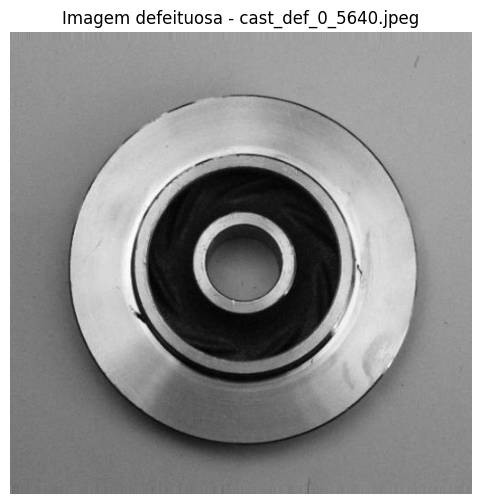

In [13]:
import random
import cv2
import matplotlib.pyplot as plt

# Escolhe aleatoriamente uma imagem defeituosa
nome_imagem = random.choice(imagens_def)

caminho_imagem = os.path.join(pasta_def, nome_imagem)

# Carrega a imagem usando OpenCV
imagem = cv2.imread(caminho_imagem)

# OpenCV carrega imagens coloridas em BGR.
# Para exibir corretamente com Matplotlib, convertemos para RGB.
imagem_rgb = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(imagem_rgb)
plt.title(f"Imagem defeituosa - {nome_imagem}")
plt.axis("off")
plt.show()

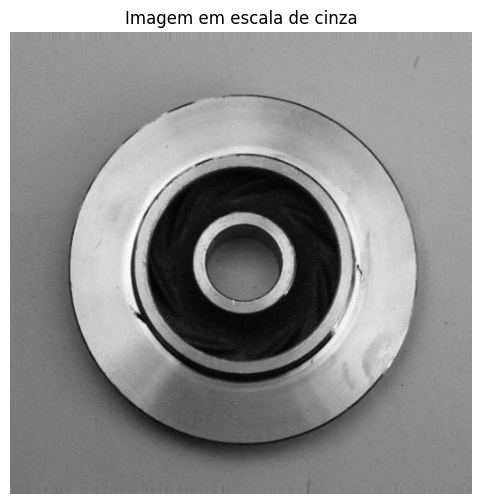

In [14]:
# Conversão para escala de cinza
cinza = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(6, 6))
plt.imshow(cinza, cmap="gray")
plt.title("Imagem em escala de cinza")
plt.axis("off")
plt.show()

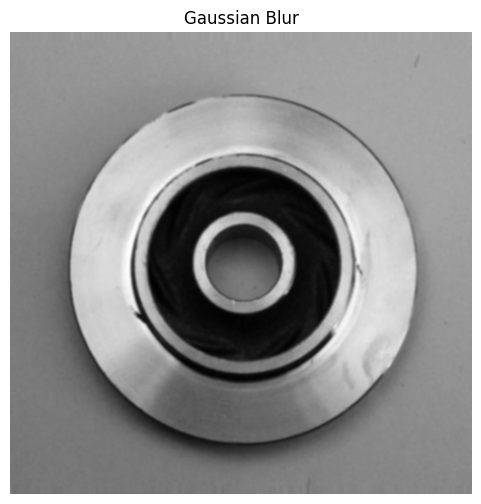

In [15]:
blur = cv2.GaussianBlur(cinza, (5, 5), 0)

plt.figure(figsize=(6, 6))
plt.imshow(blur, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")
plt.show()

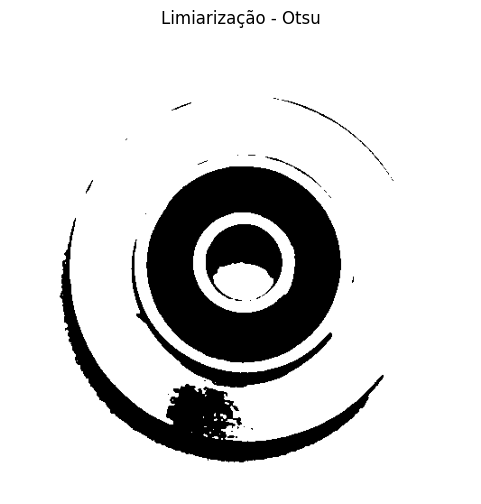

In [16]:
# Limiarização automática utilizando o método de Otsu
_, threshold = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

plt.figure(figsize=(6, 6))
plt.imshow(threshold, cmap="gray")
plt.title("Limiarização - Otsu")
plt.axis("off")
plt.show()

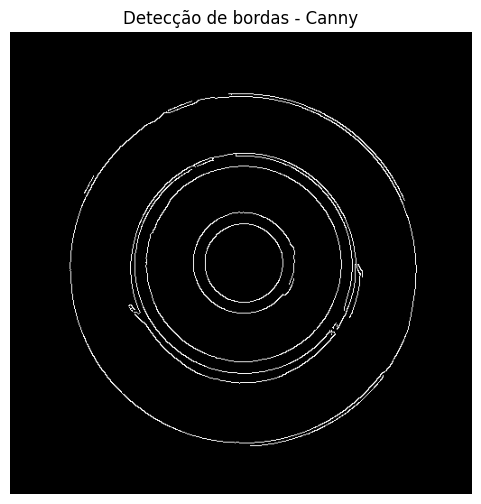

In [17]:
# Detecção de bordas utilizando Canny
bordas = cv2.Canny(blur, 50, 150)

plt.figure(figsize=(6, 6))
plt.imshow(bordas, cmap="gray")
plt.title("Detecção de bordas - Canny")
plt.axis("off")
plt.show()

In [ ]:
# 5. Operações Morfológicas

Após a detecção de bordas, serão aplicadas operações morfológicas para
tratar as regiões encontradas e reduzir pequenas imperfeições na imagem.

Serão utilizadas as operações de erosão e dilatação.

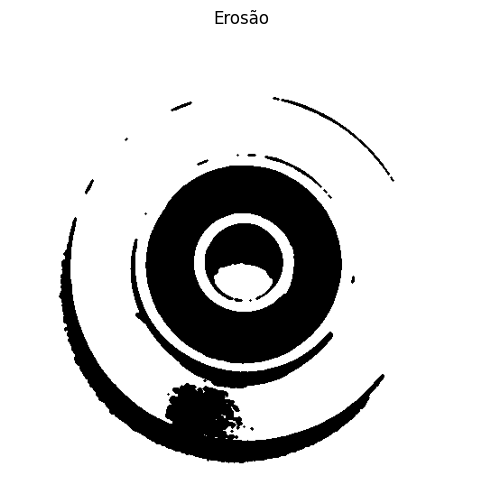

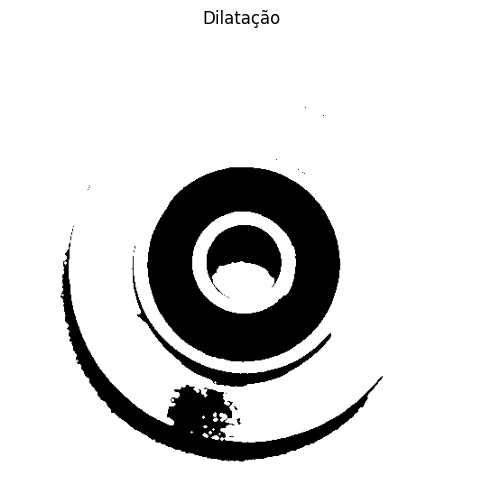

In [20]:
# Criação do elemento estruturante
kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (3, 3)
)

# Erosão
erosao = cv2.erode(threshold, kernel, iterations=1)

plt.figure(figsize=(6, 6))
plt.imshow(erosao, cmap="gray")
plt.title("Erosão")
plt.axis("off")
plt.show()

# Dilatação
dilatacao = cv2.dilate(threshold, kernel, iterations=1)

plt.figure(figsize=(6, 6))
plt.imshow(dilatacao, cmap="gray")
plt.title("Dilatação")
plt.axis("off")
plt.show()

In [ ]:
### Observação sobre os resultados

A aplicação das operações morfológicas modificou as regiões claras da imagem.
A erosão reduziu regiões e eliminou detalhes menores, enquanto a dilatação
expandiu regiões e aproximou componentes.

Os resultados demonstram que essas operações podem ser utilizadas para
redução de ruídos e tratamento das regiões detectadas, porém não isolam
individualmente o defeito. Por esse motivo, as técnicas clássicas foram
utilizadas como etapa de análise exploratória, enquanto a classificação
final será realizada pela Rede Neural Convolucional.

In [18]:
!git config --global user.name "Gustavo Mayer"
!git config --global user.email "gustavomiguelmayer@gmail.com"

In [19]:
%cd /content
!mkdir -p mini-projeto-visao-computacional
%cd /content/mini-projeto-visao-computacional
!git clone https://github.com/GustavoMMayer/mini-projeto-visao-computacional

/content
/content/mini-projeto-visao-computacional
Cloning into 'mini-projeto-visao-computacional'...
